In [1]:
import duckdb
import polars as pl
import cleaner_controller 
import pprint

In [3]:
%load_ext autoreload
%reload_ext autoreload
recording_pfad = "./recordings/Beispielaufzeichnung_2026-04-02T12-38-54_007874"

cleaner_controller.clean_all_recordings(recording_pfad)
cleaner_controller.cleanup_parquet_files(recording_pfad, dry_run=False)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Starte sequenzielle Verarbeitung für 3 Aufzeichnungen...
Überspringe (bereits vorhanden): ./recordings/Beispielaufzeichnung_2026-04-02T12-38-54_007874\recording_2026-04-02T12-39-13_999032
[1/3] ✅ recording_2026-04-02T12-39-13_999032 (Parquet erstellt)
Überspringe (bereits vorhanden): ./recordings/Beispielaufzeichnung_2026-04-02T12-38-54_007874\recording_2026-04-02T12-39-45_803167
[2/3] ✅ recording_2026-04-02T12-39-45_803167 (Parquet erstellt)
Überspringe (bereits vorhanden): ./recordings/Beispielaufzeichnung_2026-04-02T12-38-54_007874\recording_2026-04-02T12-40-17_678686
[3/3] ✅ recording_2026-04-02T12-40-17_678686 (Parquet erstellt)
┌───────────┬───────┬────────┬───────────┬─────────┬────────────────┬────────────┬────────────┬─────────┬───────────┬─────────────┬──────────────────┬─────────┬──────────────────┬──────────┬───────┬────────┐
│   Time    │ Cycle │ Value  │  Signal   │  Path   │ SamplingP

In [3]:
import duckdb

con = duckdb.connect('./duckdb.duckdb')

display(con.execute("SELECT * FROM cleaned_data WHERE DataOrigin = 'HF_Data' LIMIT 1").df())

display(con.execute("SELECT * FROM cleaned_data WHERE DataOrigin = 'LF_Data' LIMIT 1").df())

display(con.execute("SELECT * FROM cleaned_data WHERE DataOrigin = 'ET200_Data' LIMIT 1").df())

display(con.execute("""
    SELECT 
        DataOrigin, 
        COUNT(*) AS Anzahl_Zeilen,
        MIN(Time) AS Startzeit,
        MAX(Time) AS Endzeit
    FROM cleaned_data 
    GROUP BY DataOrigin
""").df())

display(con.execute("""
    SELECT 
        Nut, 
        COUNT(*) AS Anzahl_Zeilen 
    FROM cleaned_data 
    GROUP BY Nut 
    ORDER BY Nut
""").df())

con.close()

,Time,Cycle,Value,Signal,Path,SamplingPeriod,Value_Type,DataOrigin,Axisname,Unit,Groupname,Description,Nc_variable_name,Duration_Seconds,WCS_Y_mm,Nut,Platte
0,2026-01-21 14:21:52.780,1116635,0.0,CTRL_DIFF|1,None,250.0,LReal,HF_Data,X1,mm,ControlDiff,position controller input difference including...,None,0.0,-20.00001,3,1


,Time,Cycle,Value,Signal,Path,SamplingPeriod,Value_Type,DataOrigin,Axisname,Unit,Groupname,Description,Nc_variable_name,Duration_Seconds,WCS_Y_mm,Nut,Platte
0,2026-02-11 14:40:41.326134,<NA>,7339228.0,SYNC_CYCLE_HF,SYNC_CYCLE_HF,100.0,DInt,LF_Data,None,None,None,None,None,1815528.546,NaN,3,1


,Time,Cycle,Value,Signal,Path,SamplingPeriod,Value_Type,DataOrigin,Axisname,Unit,Groupname,Description,Nc_variable_name,Duration_Seconds,WCS_Y_mm,Nut,Platte
0,NaT,<NA>,4635.0,dataA1CH1,None,NaN,None,ET200_Data,None,None,None,None,None,NaN,NaN,3,1


,DataOrigin,Anzahl_Zeilen,Startzeit,Endzeit
0,LF_Data,21128,2026-02-11 14:40:41.326134,2026-02-11 14:41:31.604769
1,HF_Data,15734992,2026-01-21 14:21:52.780000,2026-01-21 14:21:54.192000
2,ET200_Data,10242276,2026-03-26 12:58:30.289000,2026-03-26 12:58:59.038000


,Nut,Anzahl_Zeilen
0,1,2188817
1,2,2188817
2,3,2188817
3,4,2188817
4,5,2138677
5,6,2138677
6,7,2138677
7,8,2138677
8,9,2172105
9,10,2172105


In [3]:
recording_pfad = "./Beispielaufzeichnung_2026-04-02T12-38-54_007874"
cleaner_controller.cleanup_parquet_files(recording_pfad, dry_run=False)


Starte Aufräumaktion...
0 Parquet-Dateien erfolgreich gelöscht!


In [7]:
import duckdb

con = duckdb.connect('./duckdb.duckdb')

query = """
SELECT 
    DataOrigin,
    COUNT(*) AS Total_Rows,
    
    -- Basis
    ROUND(100.0 * (COUNT(*) - COUNT(Time)) / COUNT(*), 2) AS Time_Null,
    ROUND(100.0 * (COUNT(*) - COUNT(Cycle)) / COUNT(*), 2) AS Cycle_Null,
    ROUND(100.0 * (COUNT(*) - COUNT(Value)) / COUNT(*), 2) AS Value_Null,
    ROUND(100.0 * (COUNT(*) - COUNT(Signal)) / COUNT(*), 2) AS Signal_Null,
    
    -- Maschine
    ROUND(100.0 * (COUNT(*) - COUNT(Path)) / COUNT(*), 2) AS Path_Null,
    ROUND(100.0 * (COUNT(*) - COUNT(SamplingPeriod)) / COUNT(*), 2) AS SamplingPeriod_Null,
    ROUND(100.0 * (COUNT(*) - COUNT(Value_Type)) / COUNT(*), 2) AS Value_Type_Null,
    ROUND(100.0 * (COUNT(*) - COUNT(Axisname)) / COUNT(*), 2) AS Axisname_Null,
    
    -- Metadaten
    ROUND(100.0 * (COUNT(*) - COUNT(Unit)) / COUNT(*), 2) AS Unit_Null,
    ROUND(100.0 * (COUNT(*) - COUNT(Groupname)) / COUNT(*), 2) AS Groupname_Null,
    ROUND(100.0 * (COUNT(*) - COUNT(Description)) / COUNT(*), 2) AS Description_Null,
    ROUND(100.0 * (COUNT(*) - COUNT(Nc_variable_name)) / COUNT(*), 2) AS Nc_variable_name_Null,
    
    -- Berechnete Features
    ROUND(100.0 * (COUNT(*) - COUNT(Duration_Seconds)) / COUNT(*), 2) AS Duration_Seconds_Null,
    ROUND(100.0 * (COUNT(*) - COUNT(WCS_Y_mm)) / COUNT(*), 2) AS WCS_Y_mm_Null,
    
    -- Tags
    ROUND(100.0 * (COUNT(*) - COUNT(Nut)) / COUNT(*), 2) AS Nut_Null,
    ROUND(100.0 * (COUNT(*) - COUNT(Platte)) / COUNT(*), 2) AS Platte_Null

FROM cleaned_data

GROUP BY DataOrigin
"""
import pandas as pd
pd.set_option('display.max_columns', None)

df_result = con.execute(query).df()
display(df_result)

con.close()

,DataOrigin,Total_Rows,Time_Null,Cycle_Null,Value_Null,Signal_Null,Path_Null,SamplingPeriod_Null,Value_Type_Null,Axisname_Null,Unit_Null,Groupname_Null,Description_Null,Nc_variable_name_Null,Duration_Seconds_Null,WCS_Y_mm_Null,Nut_Null,Platte_Null
0,HF_Data,15734992,0.00,0.0,0.0,0.0,100.0,0.0,0.0,1.1,0.0,0.0,0.0,100.0,0.00,0.0,0.0,0.0
1,ET200_Data,10242276,80.02,100.0,0.0,0.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,80.02,100.0,0.0,0.0
2,LF_Data,21128,0.00,100.0,0.0,0.0,0.0,0.0,0.0,100.0,100.0,100.0,100.0,100.0,0.00,100.0,0.0,0.0


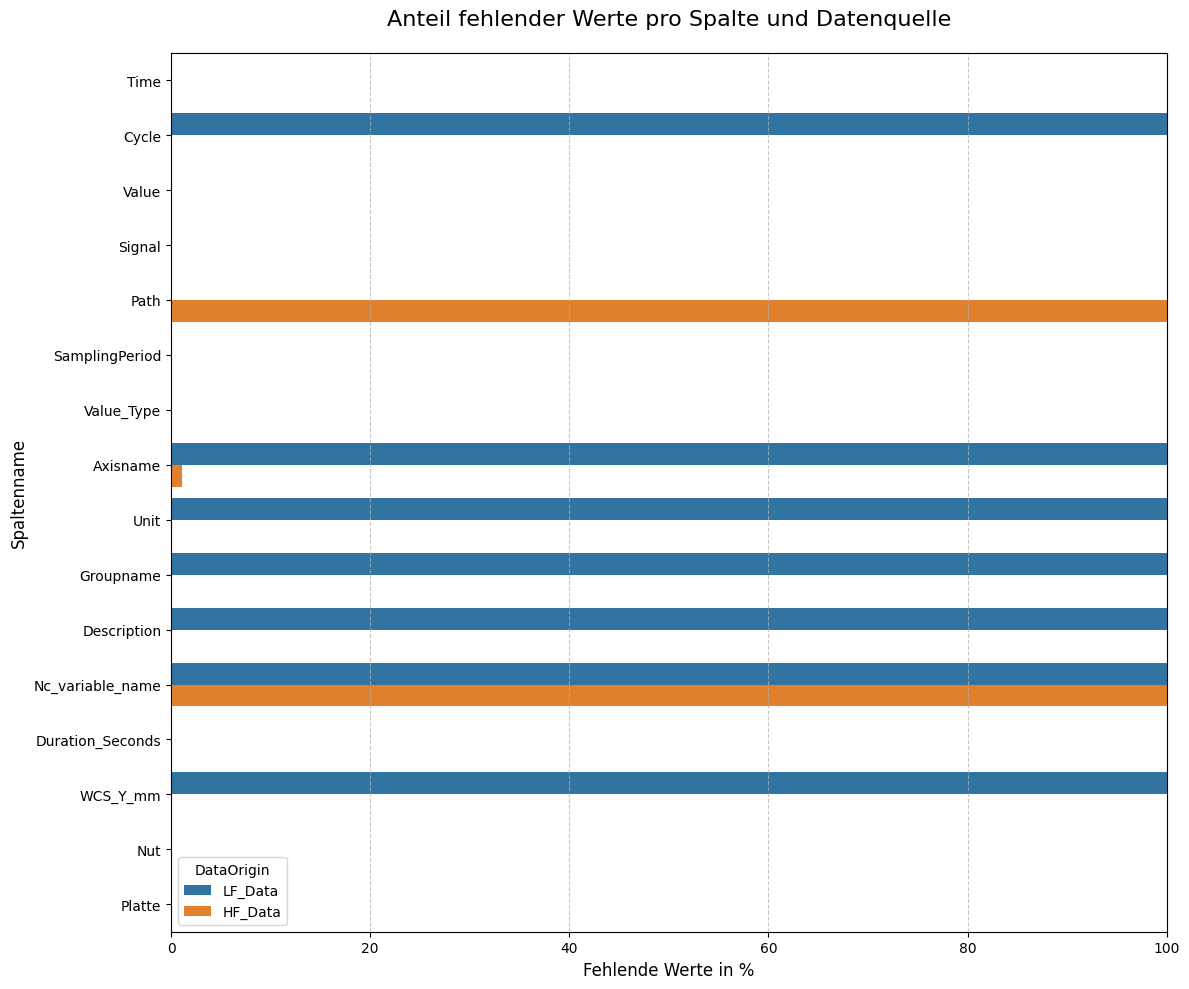

In [8]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

con = duckdb.connect('./duckdb.duckdb')

query = """
SELECT 
    DataOrigin,
    ROUND(100.0 * (COUNT(*) - COUNT(Time)) / COUNT(*), 2) AS Time_Null_Pct,
    ROUND(100.0 * (COUNT(*) - COUNT(Cycle)) / COUNT(*), 2) AS Cycle_Null_Pct,
    ROUND(100.0 * (COUNT(*) - COUNT(Value)) / COUNT(*), 2) AS Value_Null_Pct,
    ROUND(100.0 * (COUNT(*) - COUNT(Signal)) / COUNT(*), 2) AS Signal_Null_Pct,
    ROUND(100.0 * (COUNT(*) - COUNT(Path)) / COUNT(*), 2) AS Path_Null_Pct,
    ROUND(100.0 * (COUNT(*) - COUNT(SamplingPeriod)) / COUNT(*), 2) AS SamplingPeriod_Null_Pct,
    ROUND(100.0 * (COUNT(*) - COUNT(Value_Type)) / COUNT(*), 2) AS Value_Type_Null_Pct,
    ROUND(100.0 * (COUNT(*) - COUNT(Axisname)) / COUNT(*), 2) AS Axisname_Null_Pct,
    ROUND(100.0 * (COUNT(*) - COUNT(Unit)) / COUNT(*), 2) AS Unit_Null_Pct,
    ROUND(100.0 * (COUNT(*) - COUNT(Groupname)) / COUNT(*), 2) AS Groupname_Null_Pct,
    ROUND(100.0 * (COUNT(*) - COUNT(Description)) / COUNT(*), 2) AS Description_Null_Pct,
    ROUND(100.0 * (COUNT(*) - COUNT(Nc_variable_name)) / COUNT(*), 2) AS Nc_variable_name_Null_Pct,
    ROUND(100.0 * (COUNT(*) - COUNT(Duration_Seconds)) / COUNT(*), 2) AS Duration_Seconds_Null_Pct,
    ROUND(100.0 * (COUNT(*) - COUNT(WCS_Y_mm)) / COUNT(*), 2) AS WCS_Y_mm_Null_Pct,
    ROUND(100.0 * (COUNT(*) - COUNT(Nut)) / COUNT(*), 2) AS Nut_Null_Pct,
    ROUND(100.0 * (COUNT(*) - COUNT(Platte)) / COUNT(*), 2) AS Platte_Null_Pct
FROM cleaned_data
WHERE DataOrigin IN ('HF_Data', 'LF_Data')
GROUP BY DataOrigin
"""

df_result = con.execute(query).df()
con.close()

df_melted = df_result.melt(
    id_vars=['DataOrigin'],
    var_name='Feature',
    value_name='Null_Percentage'
)

df_melted['Feature'] = df_melted['Feature'].str.replace('_Null_Pct', '')

plt.figure(figsize=(12, 10))

ax = sns.barplot(
    data=df_melted, 
    y='Feature', 
    x='Null_Percentage', 
    hue='DataOrigin',
    palette=['#1f77b4', '#ff7f0e']
)

plt.title('Anteil fehlender Werte pro Spalte und Datenquelle', fontsize=16, pad=20)
plt.xlabel('Fehlende Werte in %', fontsize=12)
plt.ylabel('Spaltenname', fontsize=12)

plt.xlim(0, 100)

plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [5]:
import duckdb

con = duckdb.connect('./duckdb.duckdb')

columns_to_check = [
    'Signal', 
    'Path', 
    'SamplingPeriod', 
    'Value_Type', 
    'DataOrigin', 
    'Axis', 
    'Unit', 
    'Groupname'
]

for col in columns_to_check:
    
    query = f"""
        SELECT 
            {col}, 
            COUNT(*) AS Anzahl
        FROM cleaned_data 
        GROUP BY {col}
        ORDER BY Anzahl DESC
    """
    
    display(con.execute(query).df())

con.close()

,Signal,Anzahl
0,dataA2CH1,853523
1,dataA1CH2,853523
2,dataA1CH1,853523
3,CTRL_DIFF2|1,43228
4,CONT_DEV|1,43228
...,...,...
100,R304,440
101,R303,440
102,R305,440
103,R308,440


,Path,Anzahl
0,None,6494317
1,SYNC_CYCLE_HF,881
2,"/Channel/Parameter/r[u1,309,#1]",441
3,"/Channel/Parameter/r[u1,300,#1]",440
4,"/Channel/Parameter/r[u1,307,#1]",440
5,"/Channel/Parameter/r[u1,308,#1]",440
6,"/Channel/Parameter/r[u1,301,#1]",440
7,"/Channel/Parameter/r[u1,303,#1]",440
8,"/Channel/Parameter/r[u1,305,#1]",440
9,"/Channel/Parameter/r[u1,302,#1]",440


,SamplingPeriod,Anzahl
0,250.0,3933748
1,NaN,2560569
2,100.0,5282


,Value_Type,Anzahl
0,LReal,3938149
1,None,2560569
2,DInt,881


,DataOrigin,Anzahl
0,HF_Data,3933748
1,ET200_Data,2560569
2,LF_Data,5282


,Axis,Anzahl
0,None,2609079
1,A,648420
2,X,648420
3,Z,648420
4,Y,648420
5,B,648420
6,SP,648420


,Unit,Anzahl
0,None,2565851
1,deg,1037472
2,mm,1037472
3,Nm,518736
4,%,259368
5,deg/s,259368
6,A,259368
7,W,259368
8,mm/s,259368
9,int,43228


,Groupname,Anzahl
0,None,2565851
1,CountourDeviation,259368
2,Load,259368
3,ControlDiff2,259368
4,Encoder1Position,259368
5,Torque,259368
6,Power,259368
7,Encoder2Position,259368
8,CommandedAxisPosition,259368
9,ControlPos,259368


In [6]:
import duckdb

con = duckdb.connect('./duckdb.duckdb')

violation_query = """
    SELECT 
        Path, 
        COUNT(DISTINCT Value_Type) AS Anzahl_Value_Types,
        list(DISTINCT Value_Type) AS Verwendete_Value_Types
    FROM cleaned_data
    WHERE Path IS NOT NULL
    GROUP BY Path
    HAVING COUNT(DISTINCT Value_Type) > 1
"""

violations_df = con.execute(violation_query).df()

if not violations_df.empty:
    print("Die folgenden Pfade haben unterschiedliche Value_Types!")
    display(violations_df)
else:
    print("Jeder Pfad hat nur einen Value_Type.")


mapping_query = """
    SELECT 
        Path, 
        MAX(Value_Type) AS Value_Type
    FROM cleaned_data
    WHERE Path IS NOT NULL
    GROUP BY Path
    ORDER BY Path
"""

display(con.execute(mapping_query).df())

con.close()

Jeder Pfad hat nur einen Value_Type.


,Path,Value_Type
0,"/Channel/Parameter/r[u1,300,#1]",LReal
1,"/Channel/Parameter/r[u1,301,#1]",LReal
2,"/Channel/Parameter/r[u1,302,#1]",LReal
3,"/Channel/Parameter/r[u1,303,#1]",LReal
4,"/Channel/Parameter/r[u1,304,#1]",LReal
5,"/Channel/Parameter/r[u1,305,#1]",LReal
6,"/Channel/Parameter/r[u1,306,#1]",LReal
7,"/Channel/Parameter/r[u1,307,#1]",LReal
8,"/Channel/Parameter/r[u1,308,#1]",LReal
9,"/Channel/Parameter/r[u1,309,#1]",LReal


In [9]:
import duckdb

con = duckdb.connect('./duckdb.duckdb')

query = """
    SELECT 
        Path,
        COUNT(*) AS Total_Rows_For_Path,
        mode(Signal) AS Typical_Signal,
        mode(Value_Type) AS Typical_Value_Type,
        mode(SamplingPeriod) AS Typical_SamplingPeriod,
        mode(DataOrigin) AS Typical_DataOrigin,
        mode(Axis) AS Typical_Axis,
        mode(Unit) AS Typical_Unit,
        mode(Groupname) AS Typical_Groupname
    FROM cleaned_data
    WHERE Path IS NOT NULL
    GROUP BY Path
    ORDER BY Total_Rows_For_Path DESC
"""

display(con.execute(query).df())

con.close()

,Path,Total_Rows_For_Path,Typical_Signal,Typical_Value_Type,Typical_SamplingPeriod,Typical_DataOrigin,Typical_Axis,Typical_Unit,Typical_Groupname
0,SYNC_CYCLE_HF,881,SYNC_CYCLE_HF,DInt,100.0,LF_Data,None,None,None
1,"/Channel/Parameter/r[u1,309,#1]",441,R309,LReal,100.0,LF_Data,None,None,None
2,"/Channel/Parameter/r[u1,306,#1]",440,R306,LReal,100.0,LF_Data,None,None,None
3,"/Channel/Parameter/r[u1,300,#1]",440,R300,LReal,100.0,LF_Data,None,None,None
4,"/Channel/Parameter/r[u1,303,#1]",440,R303,LReal,100.0,LF_Data,None,None,None
5,"/Channel/Parameter/r[u1,304,#1]",440,R304,LReal,100.0,LF_Data,None,None,None
6,"/Channel/Parameter/r[u1,307,#1]",440,R307,LReal,100.0,LF_Data,None,None,None
7,"/Channel/Parameter/r[u1,301,#1]",440,R301,LReal,100.0,LF_Data,None,None,None
8,"/Channel/Parameter/r[u1,308,#1]",440,R308,LReal,100.0,LF_Data,None,None,None
9,"/Channel/Parameter/r[u1,302,#1]",440,R302,LReal,100.0,LF_Data,None,None,None


In [11]:
import duckdb

con = duckdb.connect('./duckdb.duckdb')

query = """
    SELECT 
        Path,
        COUNT(*) AS Anzahl_Zeilen
    FROM cleaned_data
    WHERE DataOrigin = 'LF_Data'
      AND Path IS NOT NULL
    GROUP BY Path
    ORDER BY Anzahl_Zeilen DESC
"""

display(con.execute(query).df())

con.close()

,Path,Anzahl_Zeilen
0,SYNC_CYCLE_HF,881
1,"/Channel/Parameter/r[u1,309,#1]",441
2,"/Channel/Parameter/r[u1,308,#1]",440
3,"/Channel/Parameter/r[u1,306,#1]",440
4,"/Channel/Parameter/r[u1,303,#1]",440
5,"/Channel/Parameter/r[u1,305,#1]",440
6,"/Channel/Parameter/r[u1,302,#1]",440
7,"/Channel/Parameter/r[u1,304,#1]",440
8,"/Channel/Parameter/r[u1,300,#1]",440
9,"/Channel/Parameter/r[u1,301,#1]",440
